In [1]:
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
import datetime
import eumdac
import netCDF4
import os
import requests
import shutil
import zipfile

import matplotlib.pyplot as plt
import numpy as np

from concurrent.futures import ThreadPoolExecutor, as_completed
from glob import glob
from io import BytesIO
from numba import jit

In [3]:
consumer_key = os.getenv('CONSUMER_KEY_EUMETSAT')
consumer_secret = os.getenv('CONSUMER_SECRET_EUMETSAT')

if not consumer_secret or not consumer_key:
    raise ValueError("Please set the environment variables CONSUMER_KEY_EUMETSAT and CONSUMER_SECRET_EUMETSAT to your EUMETSAT API credentials.")

credentials = (consumer_key, consumer_secret)

token = eumdac.AccessToken(credentials)
datastore = eumdac.DataStore(token)

print(f"This token '{token}' expires {token.expiration}")

This token 'b40d4233-66ee-3c9e-991d-629540473b25' expires 2026-10-01 12:01:25.479702


Flashes must be clustered from LI events and groups. LI events are pixels in the LI optical cameras (OC) that are illuminated above the background reference illumination and pass other quality controls. Each LI group is a collection of connected events on the same acquisition frame. There are several ways to cluster groups into flashes, but most of the time, two groups are considered part of the same flash when they are ≤ 16.5 km from each other in space and ≤ 330 ms from each other in time.

In [4]:
searchs = datastore.opensearch("""pi=EO:EUM:DAT:0687&dtstart=2024-11-12T12:41:00&dtend=2024-11-12T12:45:00""")

# Define output directory
outdir = "grid_data"

# Create the data directory if it doesn't exist
os.makedirs(outdir, exist_ok=True)

def download_and_extract(product, outdir):
    try:
        # Create a temporary BytesIO object to hold the downloaded zip file
        with product.open() as fsrc:
            with BytesIO(fsrc.read()) as bio:
                with zipfile.ZipFile(bio, 'r') as zip_ref:
                    # Check if all the files to be extracted already exist
                    all_files_exist = all(os.path.exists(os.path.join(outdir, name)) for name in zip_ref.namelist())
                    if all_files_exist:
                        print(f"All files already exist, skipping download for product: {product}")
                        return
                    # Extract all the contents into the data directory
                    zip_ref.extractall(outdir)
                    print(f'Extracted product finished.')
    except Exception as e:
        print(f"Failed to process product: {e}")

# Use ThreadPoolExecutor to handle concurrency
with ThreadPoolExecutor(max_workers=5) as executor:
    futures = {executor.submit(download_and_extract, product, outdir): product for product in searchs}
    for future in as_completed(futures):
        product = futures[future]
        try:
            future.result()
        except Exception as e:
            print(f"Exception occurred while processing product: {e}")

print("All products processed.")

All files already exist, skipping download for product: W_XX-EUMETSAT-Darmstadt,IMG+SAT,MTI1+LI-2-AFA--FD--x-x--ARC-x_C_EUMT_20241112125034_L2PF_OPE_20241112124000_20241112125000_N__O_0077_0000
All products processed.


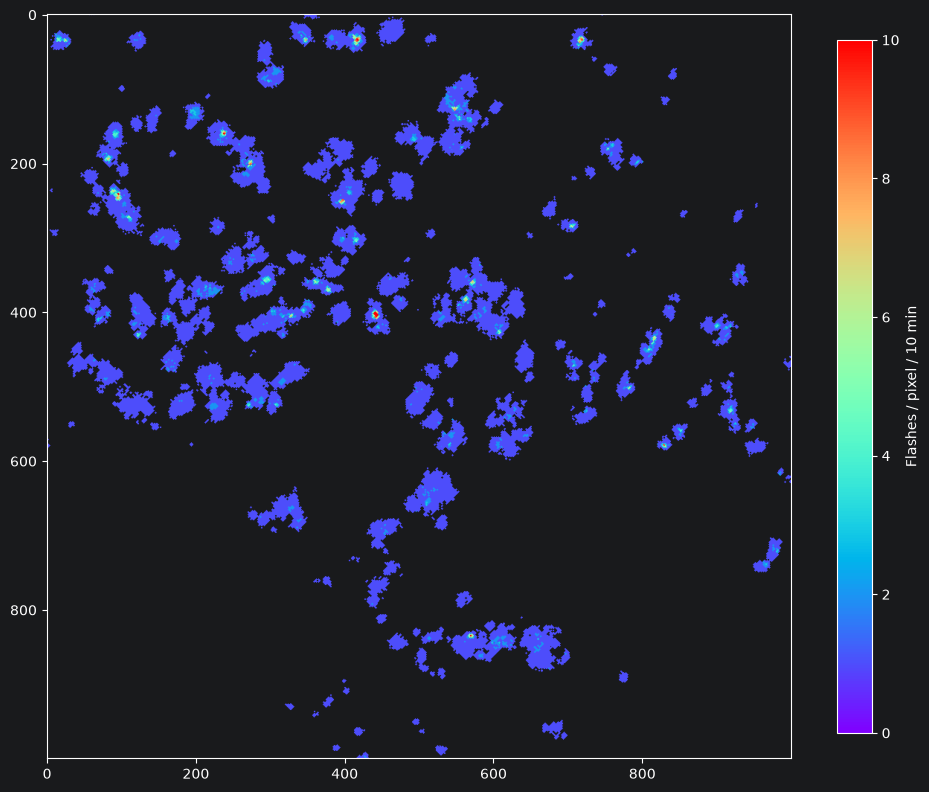

In [5]:
@jit(nopython=True)
def fill_li_grid(accums, I, J):
    """
    This function will un-sparse the LI sparse grids.
    The 2-km dimensions are hard-coded (5568,5568).
    """

    grid = np.zeros((5568,5568), dtype=np.float32)

    for ind in range(len(I)):
        grid[I[ind], J[ind]] = accums[ind]

    return grid



nc = netCDF4.Dataset(glob("grid_data/*BODY*OPE_20241112124000*.nc")[0], "r")
# The flash counts
sparse_accum = nc.variables["accumulated_flash_area"][:]
# 'Projection' coordinates
x = nc.variables['x'][:]
y = nc.variables['y'][:]
# Unscaling the projection coordinates to get the row (I) and column (J) indices
J = np.round((x - nc.variables['x'].add_offset) / nc.variables['x'].scale_factor).astype(int)
I = np.round((y - nc.variables['y'].add_offset) / nc.variables['y'].scale_factor).astype(int)
nc.close()

# Performing the unsparsing. Because we use jit to speed it up, we have to use
# numpy.ndarray instead of a masked array.
accum = np.flipud(fill_li_grid(sparse_accum.filled(0), I.filled(0), J.filled(0)))

# Now make the figure
fig = plt.figure(figsize=(12,12))
# Masking missing data and zooming in so we can see some detail.
plt.imshow(np.ma.masked_less_equal(accum[3000:4000,3500:4500], 0), vmin=0, vmax=10, cmap='rainbow')
plt.colorbar(orientation="vertical", label='Flashes / pixel / 10 min', shrink=0.75)
plt.show()

In [6]:
searchs = datastore.opensearch("""pi=EO:EUM:DAT:0662&dtstart=2024-11-12T12:41:00&dtend=2024-11-12T12:42:00""")

outdir = "fci_data"
# Create the data directory if it doesn't exist
os.makedirs(outdir, exist_ok=True)

# Use ThreadPoolExecutor to handle concurrency
with ThreadPoolExecutor(max_workers=5) as executor:
    futures = {executor.submit(download_and_extract, product, outdir): product for product in searchs}
    for future in as_completed(futures):
        product = futures[future]
        try:
            future.result()
        except Exception as e:
            print(f"Exception occurred while processing product: {e}")

print("All products processed.")

Failed to process product: Could not download Product W_XX-EUMETSAT-Darmstadt,IMG+SAT,MTI1+FCI-1C-RRAD-FDHSI-FD--x-x---x_C_EUMT_20241112124259_IDPFI_OPE_20241112124007_20241112124924_N__C_0077_0000 of Collection EO:EUM:DAT:0662 - Unauthorised (403)
All products processed.
